# 10×10 Specificity Analysis

Tracks and analyzes specificity experiments. Each experiment saves probabilities for **all 10 animal tokens** at every measurement position, enabling direct specificity testing.

**Key question:** When we target animal T, does T's probability increase *more* than the other 9 animals?

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Configuration
BASE_DIR = '/scratch/s5e/jrosser.s5e/infusion/gpt_neo/specificity'
FIGURES_DIR = '/home/s5e/jrosser.s5e/infusion/figures'

ANIMALS = ['bird', 'dog', 'bear', 'cat', 'fish',
           'rabbit', 'mouse', 'frog', 'duck', 'lion']

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

## Load Results

In [3]:
def load_all_results(base_dir=BASE_DIR):
    """Load all completed experiments from metrics.json files."""
    results = []
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"Base directory does not exist: {base_dir}")
        return pd.DataFrame()
    
    for results_dir in base_path.iterdir():
        if not results_dir.is_dir():
            continue
        
        parts = results_dir.name.split('_to_')
        if len(parts) != 2:
            continue
        
        probe, target = parts
        metrics_file = results_dir / 'metrics.json'
        
        if metrics_file.exists():
            try:
                with open(metrics_file) as f:
                    metrics = json.load(f)
                results.append({
                    'probe': probe,
                    'target': target,
                    'results_dir': str(results_dir),
                    **metrics
                })
            except Exception as e:
                print(f"Error loading {metrics_file}: {e}")
    
    return pd.DataFrame(results)


df = load_all_results()
print(f"Loaded {len(df)} / 100 experiments ({100*len(df)/100:.1f}% complete)")

if len(df) > 0:
    # Show progress grid
    progress = pd.DataFrame('', index=ANIMALS, columns=ANIMALS)
    for _, row in df.iterrows():
        if row['probe'] in ANIMALS and row['target'] in ANIMALS:
            progress.loc[row['probe'], row['target']] = 'done'
    
    n_done = (progress == 'done').sum().sum()
    n_off_diag_done = len(df[df['probe'] != df['target']])
    print(f"Off-diagonal: {n_off_diag_done} / 90")
    print(f"\nColumns: {list(df.columns)[:15]}...")
else:
    print("No results found yet. Submit the job with:")
    print("  sbatch gpt_neo/sbatch_specificity.sh")

Loaded 99 / 100 experiments (99.0% complete)
Off-diagonal: 89 / 90

Columns: ['probe', 'target', 'results_dir', 'original_model_score', 'infused_model_score', 'delta_score', 'probe_prob_shift_mean', 'target_prob_shift_mean', 'probe_log_prob_shift_mean', 'target_log_prob_shift_mean', 'animal_prob_shifts', 'animal_log_prob_shifts', 'influence_score_min', 'influence_score_max', 'influence_score_mean']...


## Delta Score Heatmap

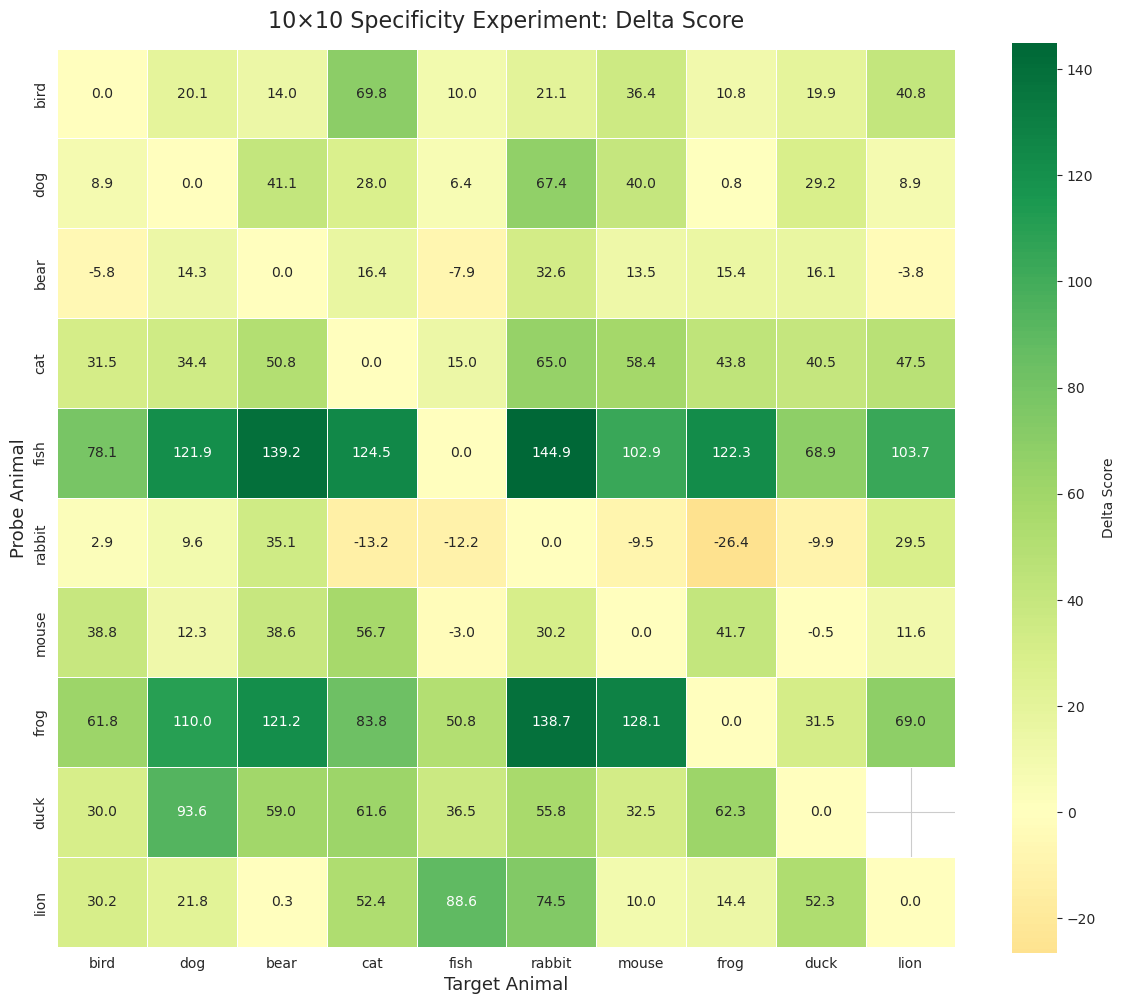

In [4]:
if len(df) > 0:
    heatmap_data = df.pivot_table(
        index='probe', columns='target',
        values='delta_score'
    ).reindex(index=ANIMALS, columns=ANIMALS)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        heatmap_data, annot=True, fmt='.1f',
        cmap='RdYlGn', center=0, ax=ax,
        linewidths=0.5, square=True,
        cbar_kws={'label': 'Delta Score'}
    )
    ax.set_title('10×10 Specificity Experiment: Delta Score', fontsize=16, pad=15)
    ax.set_xlabel('Target Animal', fontsize=13)
    ax.set_ylabel('Probe Animal', fontsize=13)
    plt.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/specificity_heatmap_delta_score.png', dpi=300, bbox_inches='tight')
    plt.show()

## Specificity Analysis

For each experiment, we now have probability shifts for **all 10 animals** at each measurement position. The key question: does the targeted animal's probability increase more than non-targeted animals?

In [5]:
if len(df) > 0 and 'animal_prob_shifts' in df.columns:
    # Extract per-animal shifts from metrics.json
    off_diag = df[df['probe'] != df['target']].copy()
    
    records = []
    for _, row in off_diag.iterrows():
        shifts = row['animal_prob_shifts']
        if isinstance(shifts, str):
            shifts = json.loads(shifts)
        target_name = row['target']
        
        for animal, shift_val in shifts.items():
            records.append({
                'probe': row['probe'],
                'target': target_name,
                'animal': animal,
                'prob_shift': shift_val,
                'is_target': animal == target_name,
                'is_probe': animal == row['probe'],
            })
    
    shift_df = pd.DataFrame(records)
    
    # Summary: targeted vs non-targeted
    targeted = shift_df[shift_df['is_target']]['prob_shift']
    non_targeted = shift_df[~shift_df['is_target'] & ~shift_df['is_probe']]['prob_shift']
    probe_shifts = shift_df[shift_df['is_probe']]['prob_shift']
    
    print('=' * 70)
    print('SPECIFICITY ANALYSIS (from metrics.json per-animal shifts)')
    print('=' * 70)
    print(f'\nTargeted animal prob shift:     mean = {targeted.mean():+.6f} (n={len(targeted)})')
    print(f'Non-targeted animal prob shift:  mean = {non_targeted.mean():+.6f} (n={len(non_targeted)})')
    print(f'Probe animal prob shift:         mean = {probe_shifts.mean():+.6f} (n={len(probe_shifts)})')
    
    # Per-experiment: mean shift of targeted vs mean shift of non-targeted
    per_exp = shift_df.groupby(['probe', 'target']).apply(
        lambda g: pd.Series({
            'target_shift': g.loc[g['is_target'], 'prob_shift'].values[0] if g['is_target'].any() else np.nan,
            'nontarget_mean_shift': g.loc[~g['is_target'] & ~g['is_probe'], 'prob_shift'].mean(),
            'probe_shift': g.loc[g['is_probe'], 'prob_shift'].values[0] if g['is_probe'].any() else np.nan,
        })
    ).reset_index()
    
    per_exp['target_advantage'] = per_exp['target_shift'] - per_exp['nontarget_mean_shift']
    
    pct_advantage = (per_exp['target_advantage'] > 0).mean() * 100
    print(f'\nTarget advantage (target_shift - mean_nontarget_shift):')
    print(f'  Mean: {per_exp["target_advantage"].mean():+.6f}')
    print(f'  Positive in {pct_advantage:.1f}% of experiments')
    
    # Wilcoxon test
    stat, pval = stats.wilcoxon(per_exp['target_shift'], per_exp['nontarget_mean_shift'])
    d = per_exp['target_advantage'].mean() / per_exp['target_advantage'].std()
    print(f'\n  Wilcoxon signed-rank p = {pval:.2e}')
    print(f'  Cohen\'s d = {d:.3f}')
    print('=' * 70)
else:
    print('Waiting for experiments with animal_prob_shifts data...')

SPECIFICITY ANALYSIS (from metrics.json per-animal shifts)

Targeted animal prob shift:     mean = +0.000258 (n=89)
Non-targeted animal prob shift:  mean = -0.000012 (n=712)
Probe animal prob shift:         mean = +0.002367 (n=89)

Target advantage (target_shift - mean_nontarget_shift):
  Mean: +0.000270
  Positive in 66.3% of experiments

  Wilcoxon signed-rank p = 1.66e-04
  Cohen's d = 0.426


/local/user/1483801484/ipykernel_241699/209183857.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_exp = shift_df.groupby(['probe', 'target']).apply(


## Specificity Plot

For each off-diagonal experiment: bar chart comparing the targeted animal's probability shift to all other animals' shifts.

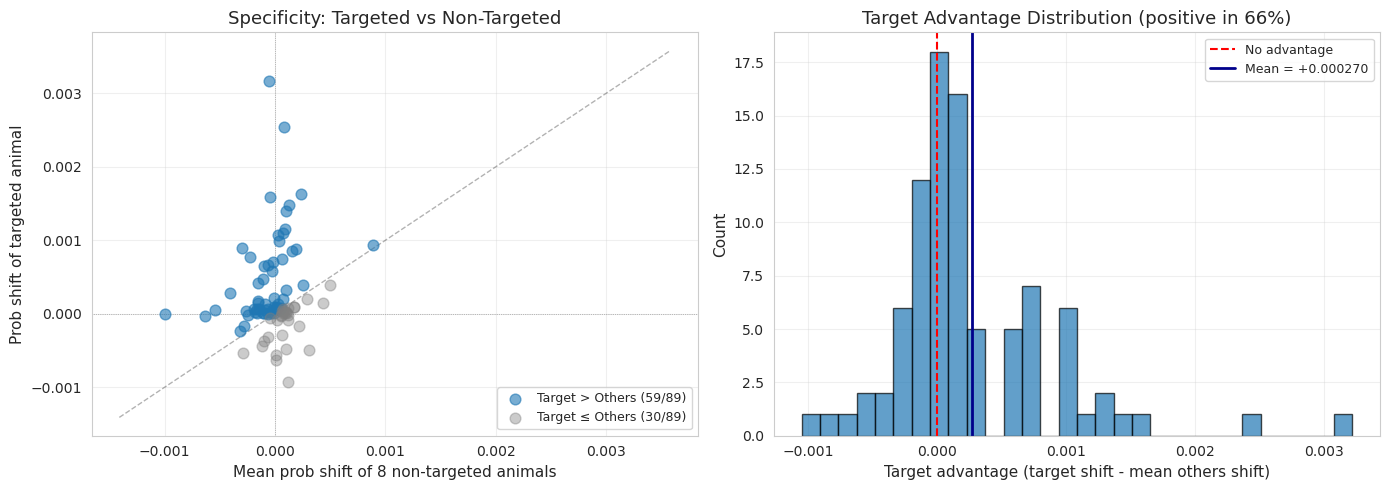

Saved to /home/s5e/jrosser.s5e/infusion/figures/specificity_scatter.{png,pdf}


In [6]:
if len(df) > 0 and 'animal_prob_shifts' in df.columns:
    off_diag = df[df['probe'] != df['target']].copy()
    
    if len(off_diag) == 0:
        print('No off-diagonal experiments yet.')
    else:
        # Compute per-experiment: targeted shift vs mean of 8 non-targeted, non-probe animals
        target_shifts = []
        nontarget_shifts = []
        
        for _, row in off_diag.iterrows():
            shifts = row['animal_prob_shifts']
            if isinstance(shifts, str):
                shifts = json.loads(shifts)
            
            target_name = row['target']
            probe_name = row['probe']
            
            target_shifts.append(shifts.get(target_name, 0))
            others = [v for k, v in shifts.items() if k != target_name and k != probe_name]
            nontarget_shifts.append(np.mean(others))
        
        target_shifts = np.array(target_shifts)
        nontarget_shifts = np.array(nontarget_shifts)
        
        # --- PLOT ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Left: scatter target_shift vs nontarget_mean_shift
        ax = axes[0]
        specific = (target_shifts > nontarget_shifts)
        ax.scatter(nontarget_shifts[specific], target_shifts[specific],
                   c='tab:blue', alpha=0.6, s=60, label=f'Target > Others ({specific.sum()}/{len(specific)})', zorder=3)
        ax.scatter(nontarget_shifts[~specific], target_shifts[~specific],
                   c='tab:gray', alpha=0.4, s=60, label=f'Target \u2264 Others ({(~specific).sum()}/{len(specific)})', zorder=3)
        
        lims = [min(nontarget_shifts.min(), target_shifts.min()),
                max(nontarget_shifts.max(), target_shifts.max())]
        margin = (lims[1] - lims[0]) * 0.1
        lims = [lims[0] - margin, lims[1] + margin]
        ax.plot(lims, lims, 'k--', alpha=0.3, lw=1)
        ax.axhline(0, color='gray', lw=0.5, ls=':')
        ax.axvline(0, color='gray', lw=0.5, ls=':')
        ax.set_xlabel('Mean prob shift of 8 non-targeted animals', fontsize=11)
        ax.set_ylabel('Prob shift of targeted animal', fontsize=11)
        ax.set_title('Specificity: Targeted vs Non-Targeted', fontsize=13)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Right: histogram of target_advantage
        ax = axes[1]
        advantage = target_shifts - nontarget_shifts
        ax.hist(advantage, bins=30, edgecolor='black', alpha=0.7, color='tab:blue')
        ax.axvline(0, color='red', ls='--', lw=1.5, label='No advantage')
        ax.axvline(advantage.mean(), color='darkblue', ls='-', lw=2,
                   label=f'Mean = {advantage.mean():+.6f}')
        ax.set_xlabel('Target advantage (target shift - mean others shift)', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(f'Target Advantage Distribution (positive in {100*specific.mean():.0f}%)', fontsize=13)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        fig.savefig(f'{FIGURES_DIR}/specificity_scatter.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{FIGURES_DIR}/specificity_scatter.pdf', bbox_inches='tight')
        plt.show()
        
        print(f'Saved to {FIGURES_DIR}/specificity_scatter.{{png,pdf}}')

## Per-Animal Specificity Breakdown

For each animal: what is its mean probability shift when it IS the target vs when it is NOT?

Per-Animal Specificity:


,shift_when_targeted,shift_when_not_targeted,n_targeted,n_not_targeted,advantage
animal,,,,,
bird,+0.000635,-0.000162,9,71,+0.000798
cat,+0.000579,-0.000116,9,71,+0.000695
frog,+0.000439,+0.000047,9,71,+0.000392
dog,+0.000322,+0.000025,9,71,+0.000297
rabbit,+0.000048,-0.000183,9,71,+0.000231
mouse,+0.000232,+0.000053,9,71,+0.000179
duck,+0.000216,+0.000117,9,72,+0.000099
fish,+0.000050,+0.000048,9,71,+0.000002
lion,-0.000080,-0.000074,8,72,-0.000006


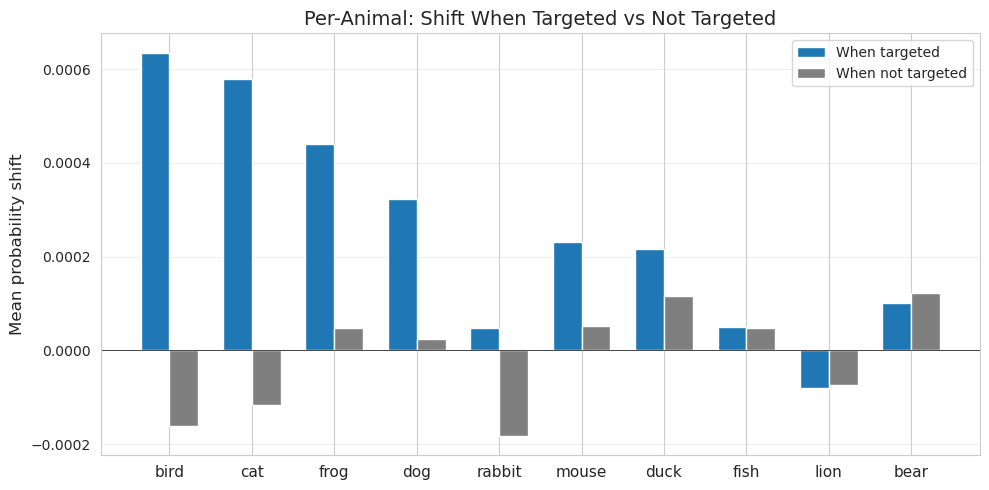

In [7]:
if 'shift_df' in dir() and len(shift_df) > 0:
    # Aggregate per animal: mean shift when targeted vs when not targeted
    per_animal = []
    for animal in ANIMALS:
        as_target = shift_df[(shift_df['animal'] == animal) & shift_df['is_target']]['prob_shift']
        not_target = shift_df[(shift_df['animal'] == animal) & ~shift_df['is_target'] & ~shift_df['is_probe']]['prob_shift']
        per_animal.append({
            'animal': animal,
            'shift_when_targeted': as_target.mean(),
            'shift_when_not_targeted': not_target.mean(),
            'n_targeted': len(as_target),
            'n_not_targeted': len(not_target),
        })
    
    pa_df = pd.DataFrame(per_animal).set_index('animal')
    pa_df['advantage'] = pa_df['shift_when_targeted'] - pa_df['shift_when_not_targeted']
    pa_df = pa_df.sort_values('advantage', ascending=False)
    
    print('Per-Animal Specificity:')
    display(pa_df.style.format({
        'shift_when_targeted': '{:+.6f}',
        'shift_when_not_targeted': '{:+.6f}',
        'advantage': '{:+.6f}',
    }))
    
    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(pa_df))
    w = 0.35
    ax.bar(x - w/2, pa_df['shift_when_targeted'], w, label='When targeted', color='tab:blue')
    ax.bar(x + w/2, pa_df['shift_when_not_targeted'], w, label='When not targeted', color='tab:gray')
    ax.set_xticks(x)
    ax.set_xticklabels(pa_df.index, fontsize=11)
    ax.set_ylabel('Mean probability shift', fontsize=12)
    ax.set_title('Per-Animal: Shift When Targeted vs Not Targeted', fontsize=14)
    ax.legend(fontsize=10)
    ax.axhline(0, color='black', lw=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/specificity_per_animal.png', dpi=300, bbox_inches='tight')
    plt.show()

## Position-Level Analysis (from visualization_data.pt)

Load the full probability arrays to analyze specificity at the individual position level.

In [10]:
if len(df) > 0:
    off_diag = df[df['probe'] != df['target']].copy()
    
    position_records = []
    n_loaded = 0
    
    for _, row in off_diag.iterrows():
        viz_path = Path(row['results_dir']) / 'visualization_data.pt'
        if not viz_path.exists():
            continue
        
        try:
            viz_data = torch.load(viz_path, map_location='cpu', weights_only=False)
            prob_data = viz_data['probability_data']
            
            if 'all_animal_probs_orig' not in prob_data:
                continue
            
            target_name = row['target']
            probe_name = row['probe']
            orig = prob_data['all_animal_probs_orig']
            inf = prob_data['all_animal_probs_inf']
            n_pos = len(orig[list(orig.keys())[0]])
            
            # At each position: is the targeted animal's shift the largest?
            target_shift = inf[target_name] - orig[target_name]
            other_shifts = []
            for name in orig:
                if name != target_name and name != probe_name:
                    other_shifts.append(inf[name] - orig[name])
            other_shifts = np.stack(other_shifts, axis=0)  # (8, N_pos)
            max_other_shift = other_shifts.max(axis=0)  # (N_pos,)
            
            target_is_max = (target_shift > max_other_shift).mean()
            target_rank = (other_shifts < target_shift[None, :]).sum(axis=0).mean()  # out of 8
            
            # Rank promotion: positions where target overtakes probe
            # Before: rank target among all 10 vs rank probe among all 10
            # A "flip" = target was ranked below probe before, but above after
            all_orig = np.stack([orig[a] for a in ANIMALS], axis=0)  # (10, N_pos)
            all_inf = np.stack([inf[a] for a in ANIMALS], axis=0)    # (10, N_pos)
            
            t_idx = ANIMALS.index(target_name)
            p_idx = ANIMALS.index(probe_name)
            
            # Before infusion: was probe ranked above target?
            probe_above_before = all_orig[p_idx] > all_orig[t_idx]  # (N_pos,)
            # After infusion: is target ranked above probe?
            target_above_after = all_inf[t_idx] > all_inf[p_idx]    # (N_pos,)
            
            # Rank flip = probe was above before AND target is above after
            rank_flips = probe_above_before & target_above_after
            rank_flip_pct = rank_flips.mean() * 100
            
            # Also: target above probe after (regardless of before)
            target_above_after_pct = target_above_after.mean() * 100
            
            position_records.append({
                'probe': probe_name,
                'target': target_name,
                'n_positions': n_pos,
                'target_is_max_pct': target_is_max * 100,
                'target_mean_rank': target_rank,
                'target_shift_mean': target_shift.mean(),
                'max_other_shift_mean': max_other_shift.mean(),
                'rank_flip_pct': rank_flip_pct,
                'target_above_after_pct': target_above_after_pct,
            })
            n_loaded += 1
        except Exception as e:
            print(f'Error loading {viz_path.name}: {e}')
    
    print(f'Loaded position-level data from {n_loaded} experiments')
    
    if position_records:
        pos_df = pd.DataFrame(position_records)
        
        print(f'\n{"="*70}')
        print('POSITION-LEVEL SPECIFICITY')
        print(f'{"="*70}')
        print(f'Target has largest shift (among 9 non-probe animals):')
        print(f'  Mean across experiments: {pos_df["target_is_max_pct"].mean():.1f}%')
        print(f'  (Chance level = {100/9:.1f}%)')
        print(f'\nTarget mean rank among 8 non-probe animals (8=best):')
        print(f'  Mean: {pos_df["target_mean_rank"].mean():.2f}')
        print(f'  (Chance level = 4.0)')
        print(f'\nRank flips (target overtakes probe):')
        print(f'  Mean across experiments: {pos_df["rank_flip_pct"].mean():.1f}% of positions')
        print(f'  Median: {pos_df["rank_flip_pct"].median():.1f}%')
        print(f'\nTarget ranked above probe after infusion:')
        print(f'  Mean: {pos_df["target_above_after_pct"].mean():.1f}% of positions')
        print(f'{"="*70}')

Loaded position-level data from 89 experiments

POSITION-LEVEL SPECIFICITY
Target has largest shift (among 9 non-probe animals):
  Mean across experiments: 30.5%
  (Chance level = 11.1%)

Target mean rank among 8 non-probe animals (8=best):
  Mean: 5.53
  (Chance level = 4.0)

Rank flips (target overtakes probe):
  Mean across experiments: 0.1% of positions
  Median: 0.0%

Target ranked above probe after infusion:
  Mean: 3.2% of positions


## Rank Flip Grid

For each (probe, target) pair: what percentage of measurement positions see the target's probability overtake the probe's after infusion (when it was below before)?

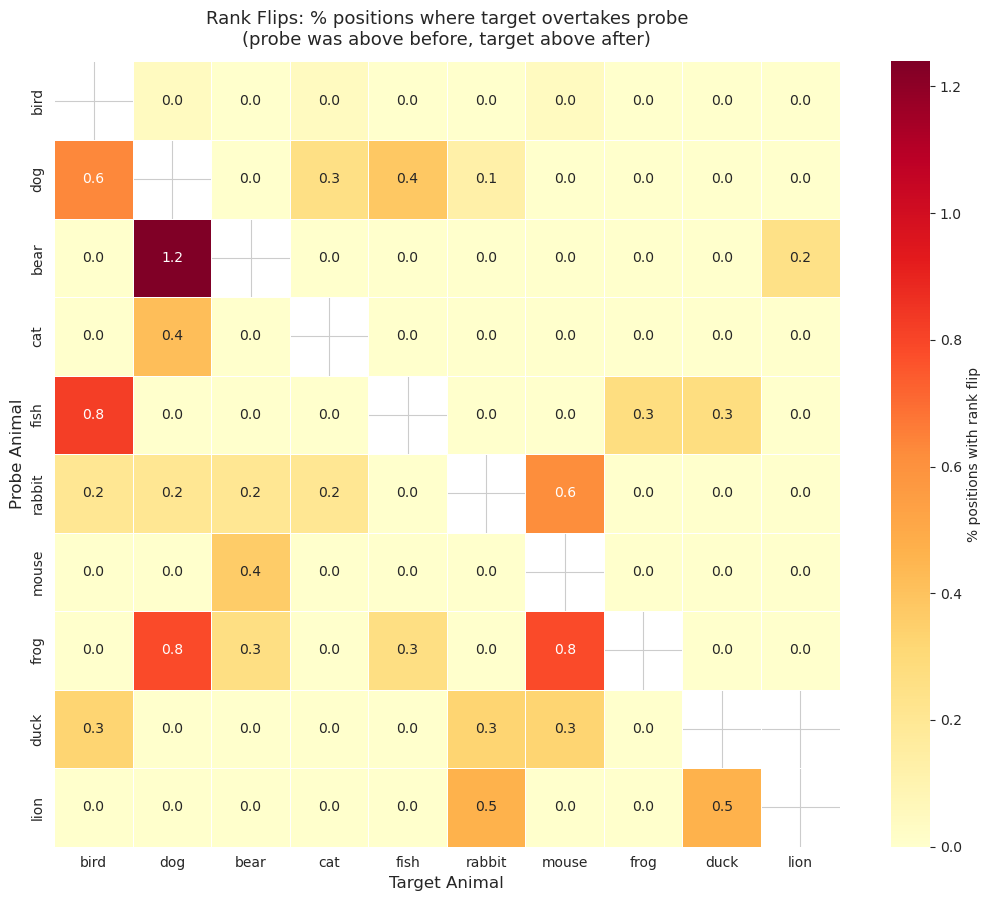

In [17]:
if 'pos_df' in dir() and len(pos_df) > 0:
    # Rank flip heatmap
    flip_grid = pos_df.pivot_table(
        index='probe', columns='target',
        values='rank_flip_pct'
    ).reindex(index=ANIMALS, columns=ANIMALS)
    
    plt.figure(figsize=(11, 9))
    ax = plt.gca()
    sns.heatmap(
        flip_grid, annot=True, fmt='.1f',
        cmap='YlOrRd', ax=ax,
        linewidths=0.5, square=True,
        vmin=0,
        cbar_kws={'label': '% positions with rank flip'}
    )
    ax.set_title('Rank Flips: % positions where target overtakes probe\n'
                 '(probe was above before, target above after)', fontsize=13, pad=12)
    ax.set_xlabel('Target Animal', fontsize=12)
    ax.set_ylabel('Probe Animal', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/ ', dpi=300, bbox_inches='tight')
    plt.savefig(f'{FIGURES_DIR}/specificity_rank_flip_grid.pdf', bbox_inches='tight')
    plt.savefig(f'{FIGURES_DIR}/specificity_rank_flip_grid.png', bbox_inches='tight')
    plt.show()

## Summary

In [16]:
if len(df) > 0:
    off_diag = df[df['probe'] != df['target']]
    print('=' * 70)
    print('EXPERIMENT SUMMARY')
    print('=' * 70)
    print(f'Completed: {len(df)} / 100 experiments')
    print(f'Off-diagonal: {len(off_diag)} / 90')
    if len(off_diag) > 0:
        print(f'\nDelta Score:')
        print(f'  Mean: {off_diag["delta_score"].mean():.1f} \u00b1 {off_diag["delta_score"].std():.1f}')
        print(f'  Median: {off_diag["delta_score"].median():.1f}')
    print('=' * 70)

EXPERIMENT SUMMARY
Completed: 99 / 100 experiments
Off-diagonal: 89 / 90

Delta Score:
  Mean: 42.3 ± 39.9
  Median: 34.4


## PGD Perturbation Statistics

Compute aggregate token-change statistics across all experiments for Insight 7.

In [18]:
if len(df) > 0:
    # PGD perturbation statistics from metrics.json
    # These are needed for Insight 7 in the paper
    off_diag = df[df['probe'] != df['target']]
    
    print('=' * 70)
    print('PGD PERTURBATION STATISTICS (for Insight 7)')
    print('=' * 70)
    
    if 'token_changes_mean' in df.columns:
        tc = off_diag['token_changes_mean']
        pct = off_diag['percent_tokens_changed']
        seq_len = off_diag['avg_sequence_length']
        
        print(f'\nTokens changed per document:')
        print(f'  Mean across experiments: {tc.mean():.1f} ± {tc.std():.1f}')
        print(f'  Median: {tc.median():.1f}')
        print(f'  Range: [{tc.min():.1f}, {tc.max():.1f}]')
        
        print(f'\nAverage sequence length: {seq_len.mean():.1f} tokens')
        
        print(f'\nPercent of sequence changed per document:')
        print(f'  Mean: {pct.mean():.1f}%')
        print(f'  Median: {pct.median():.1f}%')
        
        # Fraction of retrain segment changed
        # 100 docs perturbed, 64000 docs in retrain segment
        n_docs_perturbed = 100
        n_docs_retrain = 64000
        mean_tokens_changed = tc.mean()
        mean_seq_len = seq_len.mean()
        
        # Total tokens changed / total tokens in retrain segment
        total_tokens_changed = n_docs_perturbed * mean_tokens_changed
        total_tokens_retrain = n_docs_retrain * mean_seq_len
        frac_retrain = total_tokens_changed / total_tokens_retrain * 100
        
        print(f'\nFraction of retrain segment changed:')
        print(f'  {n_docs_perturbed} docs × {mean_tokens_changed:.1f} tokens = {total_tokens_changed:.0f} tokens changed')
        print(f'  {n_docs_retrain} docs × {mean_seq_len:.0f} tokens = {total_tokens_retrain:.0f} total tokens')
        print(f'  = {frac_retrain:.3f}% of retrain segment')
        
        print(f'\n--- Values for paper (Insight 7) ---')
        print(f'  ~{tc.mean():.0f} tokens per document (~{pct.mean():.0f}% of the sequence), just {frac_retrain:.2f}% of the retrain segment')
    else:
        print('token_changes_mean not found in metrics. Available columns:')
        print([c for c in df.columns if 'token' in c.lower() or 'change' in c.lower()])
    
    print('=' * 70)

PGD PERTURBATION STATISTICS (for Insight 7)

Tokens changed per document:
  Mean across experiments: 19.1 ± 14.7
  Median: 14.5
  Range: [3.6, 76.0]

Average sequence length: 198.4 tokens

Percent of sequence changed per document:
  Mean: 9.7%
  Median: 7.2%

Fraction of retrain segment changed:
  100 docs × 19.1 tokens = 1913 tokens changed
  64000 docs × 198 tokens = 12699542 total tokens
  = 0.015% of retrain segment

--- Values for paper (Insight 7) ---
  ~19 tokens per document (~10% of the sequence), just 0.02% of the retrain segment
